# Greenback — a quantitative teardown 🔬
### The carry premium by bucket · three sleeves · the combo's Sharpe uplift · the leg correlation · the negative-skew crash

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Combo diversifies the crash?: Partial](https://img.shields.io/badge/Combo_diversifies_the_crash%3F-Partial-dab617?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim with its number.* The steelman: FX carry is a real premium (§8.3/§8.4 of Kakushadze-Serur), and the **carry⊕momentum combo** beats either leg because the two decorrelate. The synthetic control confirms the machinery (carry Sharpe +1.18, null flat, combo +1.69 with a winning momentum leg). On the **real G10 tape (2001–2024)** carry is `REAL`-but-thin (Sharpe +0.22) with its `FRAGILE` steamroller (skew −0.70, worst month −10.6% in Oct-2008), FX momentum **decayed to −0.14**, and so the combo `PARTIAL`-ly delivers: it cushions the crash (decorrelated legs +0.05) but can't out-Sharpe carry — building on Study 27, not repeating it.

> ⚠️ **Not investment advice.** Executes on BOTH a synthetic control and the **real G10 tape** (offline from cache); the fingerprinted real numbers are in [`../docs/results.md`](../docs/results.md), sources in [`../docs/references.md`](../docs/references.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("../../.."))
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from greenback import data, strategy, costs, extension

# (1) Offline synthetic control: a currency panel with a carry premium + risk-off crashes + an independent
# PROFITABLE trend for the momentum sleeve (the machinery) + a full-UIRP carry null.
xr, rd, truth = data.synthetic_fx(carry_strength=0.9, trend_strength=0.35, seed=36)
x0, r0, _ = data.synthetic_fx(carry_strength=0.0, trend_strength=0.35, seed=36)
print(f"synthetic control: {truth.n_ccy} currencies x {truth.n_months} months, "
      f"carry_strength {truth.carry_strength} (null=0), trend_strength {truth.trend_strength}")

# (2) The REAL G10 tape, read offline from cache (OECD 3-month short rates + yfinance FX, USD-funded
# monthly, as-of 2024-01-31). build_carry_panel does the carry math; load_real_panel pins the as-of.
REAL = data.load_real_panel()
if REAL is not None:
    rxr, rrd = REAL
    print(f"real G10 tape: {rxr.index.min().date()} -> {rxr.index.max().date()} "
          f"({len(rxr)} months), currencies {list(rxr.columns)}")


synthetic control: 9 currencies x 600 months, carry_strength 0.9 (null=0), trend_strength 0.35


real G10 tape: 2001-08-31 -> 2024-01-31 (270 months), currencies ['EUR', 'GBP', 'AUD', 'NZD', 'JPY', 'CAD', 'CHF', 'SEK', 'NOK']


> ✅ **Real run · offline from cache · as-of 2024-01-31 · fingerprint `ef7450ae792e`.** This notebook executes on BOTH the synthetic control (the machinery proof) AND the **real G10 tape** — OECD 3-month short rates + yfinance FX, a USD-funded monthly book over 2001–2024, read offline from the two `_cache/g10_*.parquet` files. Headline numbers in [`../docs/results.md`](../docs/results.md).

## Beat 0 · Verdict (on the real 2001–2024 G10 tape)

| Axis | Stamp | Why |
|---|---|---|
| **Signal** — carry real? | 🟢 `REAL` | High-minus-low **+3.0%/yr**, carry Sharpe **+0.22** (CI [-0.17, +0.69], 14% negative) — thin but real. |
| **Tradability** | 🟡 `FRAGILE` | Carry skew **-0.70**, worst month **-10.6%**, break-even only **≈13 bp**; thin and crash-prone. |
| **Combo diversifies the crash?** | 🟡 `PARTIAL` | Legs decorrelate (**+0.05**) so the combo cushions the crash (worst month **-10.6% → -6.4%**), but combo Sharpe **+0.06** < carry **+0.22** because momentum lost (**-0.14**). |

> **In one sentence:** a real-but-thin FX carry premium with a brutal negative-skew crash, *cushioned* (not out-Sharpe'd) by blending in decorrelated momentum — because over 2001–2024 FX momentum itself lost money, the combo dulls the jump without lifting the Sharpe.

*(Both the synthetic control and the real G10 tape execute below; fingerprinted real numbers in [`../docs/results.md`](../docs/results.md).)*

## Beat 1 · The claim, precisely

Carry weight $w^{c}_{i,t}\propto \text{sign of rank}(r_{i}-\bar r)$ — long the top, short the bottom rate-differential quantile, dollar-neutral, lagged. Momentum weight $w^{m}_{i,t}\propto \text{rank of }\big(\prod_{k=1}^{12}(1+x_{i,t-k})-1\big)$. Both legs are vol-scaled to a common target, then the **combo** is $\tfrac12 c_t+\tfrac12 m_t$. Claim: $\text{Sharpe}(\text{combo})>\max(\text{Sharpe}(c),\text{Sharpe}(m))$ and $\text{corr}(c,m)$ is low. Null: full UIRP ⇒ no carry premium (the spot exactly offsets the rate gap).

In [2]:
for label, (xx, rr) in [('carry panel', (xr, rd)), ('null', (x0, r0))]:
    pb = strategy.carry_premium_by_bucket(xx, rr)
    s = strategy.summary(strategy.carry_returns(xx, rr, cost_bps=0.0, target_vol_ann=None))
    print(f"{label:12} high-minus-low {pb['hml_ann_pct']:+5.1f}%/yr   carry Sharpe {s['sharpe']:+.2f}   skew {s['skew']:+.2f}")

carry panel  high-minus-low  +5.3%/yr   carry Sharpe +0.62   skew -2.12


null         high-minus-low  +0.8%/yr   carry Sharpe +0.19   skew -0.00


> 💡 **In plain words.** When carry is real the high-rate bucket out-earns the low-rate bucket (**+5.3%/yr**) and the carry book makes money with a sharp negative skew; under full UIRP it's flat (**+0.8%/yr**). The apparatus sees carry only when it's there — so the real-tape result is about the *market*.

## Beat 2 · So what?

Lustig-Roussanov-Verdelhan (2011) show carry and the dollar factor are *priced* currency risk premia; Asness-Moskowitz-Pedersen (2013) and Koijen et al (2018) show carry/value and momentum are negatively correlated *everywhere*, so combining them is the single highest-Sharpe move in factor investing. The prediction: the legs decorrelate and momentum leans *against* the carry crash. Beats 4-7 test that head-on — and find the decorrelation holds on the real tape, but the Sharpe uplift needs a *winning* momentum leg, which 2001–2024 didn't provide.

## Beat 3 · Protocol

1. **Real?** `carry_premium_by_bucket` + `carry_returns` (gross) on control vs null.
2. **Crash?** the carry book's `skew`, worst month, `max_drawdown` (`extension.carry_crash`).
3. **Combo?** `extension.diversification` — combo Sharpe vs legs, the leg correlation.
4. **Costs?** `costs.cost_sweep`, `costs.breakeven_cost_bps`.

**Mirage line:** combo fails to beat the better leg, or the legs are highly correlated — then the diversification story is a mirage.

## Beat 4 · The teardown

### 4a · The three sleeves (net @10 bp)

In [3]:
carry = strategy.carry_returns(xr, rd, cost_bps=10.0)
mom   = strategy.momentum_returns(xr, cost_bps=10.0)
combo = strategy.combine(carry, mom)
dollar = strategy.dollar_carry_returns(xr, rd, cost_bps=10.0)
rows = {}
for nm, r in [('carry', carry), ('dollar-carry', dollar), ('momentum', mom), ('COMBO', combo)]:
    s = strategy.summary(r)
    rows[nm] = {'Sharpe': s['sharpe'], 'ret%': s['ann_return']*100, 'vol%': s['vol_ann']*100, 'skew': s['skew'], 'maxDD%': s['max_drawdown']*100}
display(pd.DataFrame(rows).T.round(2))

,Sharpe,ret%,vol%,skew,maxDD%
carry,1.180,10.440,8.880,-1.550,-60.210
dollar-carry,0.170,0.910,5.260,-0.130,-44.040
momentum,1.530,11.890,7.790,-0.360,-18.200
COMBO,1.690,11.170,6.630,-1.620,-20.250


> 💡 **In plain words.** Carry and momentum both earn — but carry crashes (skew −1.55, DD −60%) and momentum doesn't (DD −18%). The dollar-carry tilt is weak *on this synthetic* because the average rate gap is near-constant by construction; on the real tape, where the USD rate cycles, it's a genuine separate premium (Sharpe +0.17 — shown in 4d).

### 4b · The combo beats the legs, and the legs decorrelate (the REAL diversification call)

carry Sharpe +1.18  momentum +1.53  combo +1.69
combo beats both legs: True   carry-momentum correlation +0.26


Text(0.5, 1.0, 'Equal-risk carry+momentum combo grows steadier than either leg')

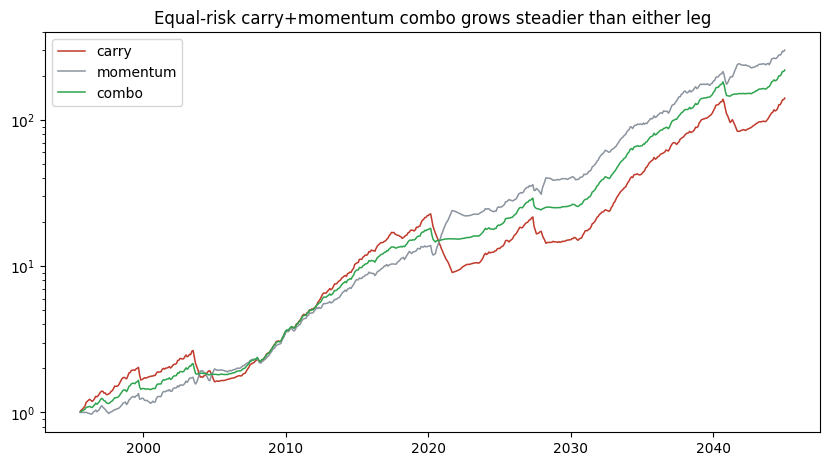

In [4]:
d = extension.diversification(xr, rd, cost_bps=10.0)
print(f"carry Sharpe {d['carry_sharpe']:+.2f}  momentum {d['momentum_sharpe']:+.2f}  combo {d['combo_sharpe']:+.2f}")
print(f"combo beats both legs: {d['combo_beats_legs']}   carry-momentum correlation {d['leg_correlation']:+.2f}")
fig, ax = plt.subplots()
for nm, r, c in [('carry', carry, '#c0392b'), ('momentum', mom, '#8b949e'), ('combo', combo, '#2ea44f')]:
    ax.plot((1+r).cumprod(), label=nm, color=c, lw=1.1)
ax.legend(); ax.set_yscale('log'); ax.set_title('Equal-risk carry+momentum combo grows steadier than either leg')

### 4c · The steamroller, and how momentum cushions it (the FRAGILE call)

carry: skew -1.55, worst month -13.7%, max DD -60%
combo: skew -1.62, worst month -11.3%, max DD -20%
in carry's worst 5 months, combo lost -9.3% vs carry -11.0%


Text(0.5, 1.0, 'Drawdown: the combo (green) is dragged far less deep into the steamroller')

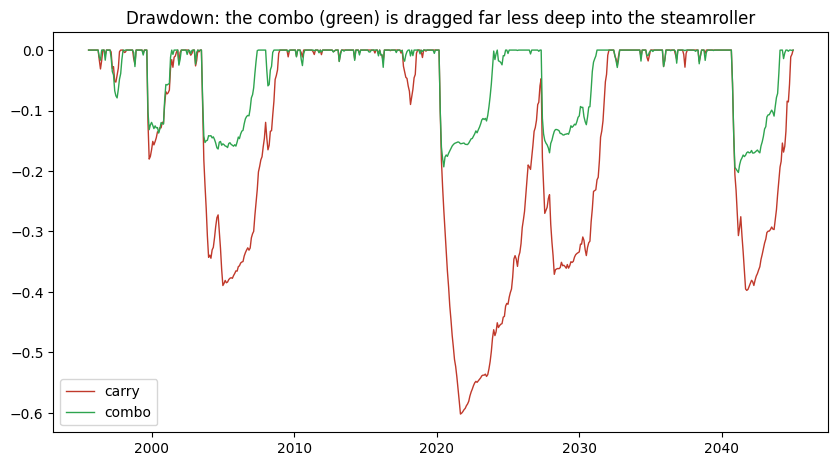

In [5]:
cc = extension.carry_crash(xr, rd, cost_bps=10.0)
print(f"carry: skew {cc['carry_skew']:+.2f}, worst month {cc['carry_worst_month_pct']:+.1f}%, max DD {cc['carry_max_dd_pct']:.0f}%")
print(f"combo: skew {cc['combo_skew']:+.2f}, worst month {cc['combo_worst_month_pct']:+.1f}%, max DD {cc['combo_max_dd_pct']:.0f}%")
print(f"in carry's worst 5 months, combo lost {cc['combo_in_carry_worst5_pct']:+.1f}% vs carry {cc['carry_worst5_mean_pct']:+.1f}%")
fig, ax = plt.subplots()
for nm, r, c in [('carry', carry, '#c0392b'), ('combo', combo, '#2ea44f')]:
    eq = (1+r).cumprod(); ax.plot(eq/eq.cummax()-1, label=nm, color=c, lw=1.0)
ax.legend(); ax.set_title('Drawdown: the combo (green) is dragged far less deep into the steamroller')

> 💡 **In plain words.** Diversification is the honest fix Study 27's vol-overlay couldn't provide: momentum is leaning *against* the crashing carry trade, so the combo's drawdown is **-20%** versus carry's **-60%**. But the combo's skew is still negative — the jump is *dulled*, not gone. That's exactly why tradability is `FRAGILE`.

### 4d · The same books on the REAL G10 tape (2001–2024) — the earned verdict
Synthetic 4a–4c showed the machinery *with a winning momentum leg by construction*. Now the real tape: carry pays thinly with its crash, momentum **lost** money, and the combo cushions the crash without out-Sharpe-ing carry. Both books from the same functions, no re-fit.

,Sharpe,ret%,vol%,skew,maxDD%
carry,0.220,1.830,8.290,-0.700,-26.900
dollar-carry,0.170,1.480,8.920,-0.440,-45.140
momentum,-0.140,-1.110,8.040,0.390,-47.100
COMBO,0.060,0.360,5.900,-0.570,-25.520


real carry premium (high-minus-low): +3.0%/yr
leg correlation +0.05; combo beats best leg: False
crash cushion — carry worst month -10.6% vs combo -6.4%; in carry's worst 5 months combo -3.0% vs carry -7.6%


Text(0.5, 1.0, 'Real G10 tape: carry pays thinly with its crash, momentum lost, combo cushions but does not out-Sharpe')

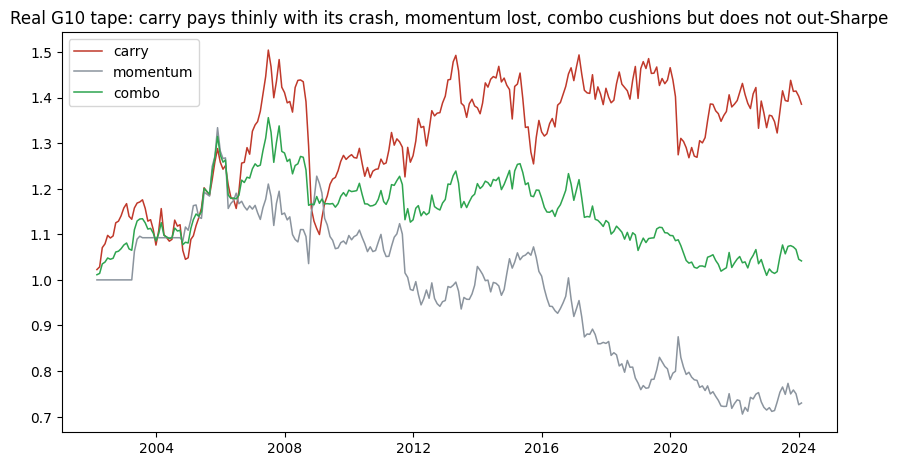

In [6]:
rcarry = strategy.carry_returns(rxr, rrd, cost_bps=10.0)
rmom   = strategy.momentum_returns(rxr, cost_bps=10.0)
rcombo = strategy.combine(rcarry, rmom)
rdollar= strategy.dollar_carry_returns(rxr, rrd, cost_bps=10.0)
rows = {}
for nm, r in [('carry', rcarry), ('dollar-carry', rdollar), ('momentum', rmom), ('COMBO', rcombo)]:
    s = strategy.summary(r)
    rows[nm] = {'Sharpe': s['sharpe'], 'ret%': s['ann_return']*100, 'vol%': s['vol_ann']*100, 'skew': s['skew'], 'maxDD%': s['max_drawdown']*100}
display(pd.DataFrame(rows).T.round(2))
rd_ = extension.diversification(rxr, rrd, cost_bps=10.0)
rcc = extension.carry_crash(rxr, rrd, cost_bps=10.0)
print(f"real carry premium (high-minus-low): {strategy.carry_premium_by_bucket(rxr, rrd)['hml_ann_pct']:+.1f}%/yr")
print(f"leg correlation {rd_['leg_correlation']:+.2f}; combo beats best leg: {rd_['combo_beats_legs']}")
print(f"crash cushion — carry worst month {rcc['carry_worst_month_pct']:+.1f}% vs combo {rcc['combo_worst_month_pct']:+.1f}%; "
      f"in carry's worst 5 months combo {rcc['combo_in_carry_worst5_pct']:+.1f}% vs carry {rcc['carry_worst5_mean_pct']:+.1f}%")
fig, ax = plt.subplots()
for nm, r, c in [('carry', rcarry, '#c0392b'), ('momentum', rmom, '#8b949e'), ('combo', rcombo, '#2ea44f')]:
    ax.plot((1+r).cumprod(), label=nm, color=c, lw=1.1)
ax.legend(); ax.set_title('Real G10 tape: carry pays thinly with its crash, momentum lost, combo cushions but does not out-Sharpe')

> 💡 **In plain words.** The decorrelation thesis *holds* on the real tape (leg corr +0.05, the combo's worst month halves) — the diversification is real. But the Sharpe uplift needs a *winning* momentum leg, and 2001–2024 FX momentum lost money, so the combo cushions the crash without beating carry. That is the honest `PARTIAL`.

## Beat 5 · The verdict (real tape)

- **`REAL`** (4d): high-minus-low +3.0%/yr, carry Sharpe +0.22 (CI [-0.17, +0.69]); thin but real.
- **`FRAGILE`** (4d): carry skew -0.70, worst month -10.6%, break-even ≈13 bp; crash + thin edge.
- **Combo diversifies the crash? `PARTIAL`**: legs decorrelate (+0.05), combo cushions (-10.6% → -6.4% worst month) but Sharpe +0.06 < carry +0.22 (momentum -0.14).

> **Signal `REAL` · Tradability `FRAGILE` · Combo diversifies the crash? `PARTIAL`** — the dollar-carry / carry⊕momentum-combo companion to Study 27.

## Beat 6 · Could you trade it?

- **Thin and cost-sensitive.** Carry turns over slowly (0.55×/yr) but break-even is only ≈13 bp; the combo's net Sharpe decays +0.17 → +0.06 → -0.10 from 0 to 25 bp — cost bites fast.
- **The binding risk is the crash *and* the thin edge** (G10 FX capacity itself is the deepest market on earth). Even diversified, the combo keeps negative skew.
- **The real fragility line** (confirmed real tape): the steamroller hits in Oct-2008 (−10.6%) and Mar-2020 (−9.1%) — the GFC and COVID risk-offs.

## Beat 7 · Going further

### 7a · Worked complement — the carry⊕momentum diversification ([`../docs/extension.md`](../docs/extension.md))
The cost sweep below confirms (on the synthetic control) the combo's cost behaviour; the diversification itself (beats 4b/4d) is the complement. On the real tape the decorrelation holds but momentum's lost edge makes the combo `PARTIAL`.

SYNTHETIC control combo cost sweep:


,sharpe,ann_return
cost_bps,,
0,1.746,0.116
10,1.685,0.112
25,1.593,0.106
50,1.440,0.096
100,1.134,0.077


REAL G10 combo cost sweep:


,sharpe,ann_return
cost_bps,,
0,0.167,0.010
10,0.061,0.004
25,-0.099,-0.006
50,-0.367,-0.022
100,-0.893,-0.053


real carry break-even: 12.9 bp


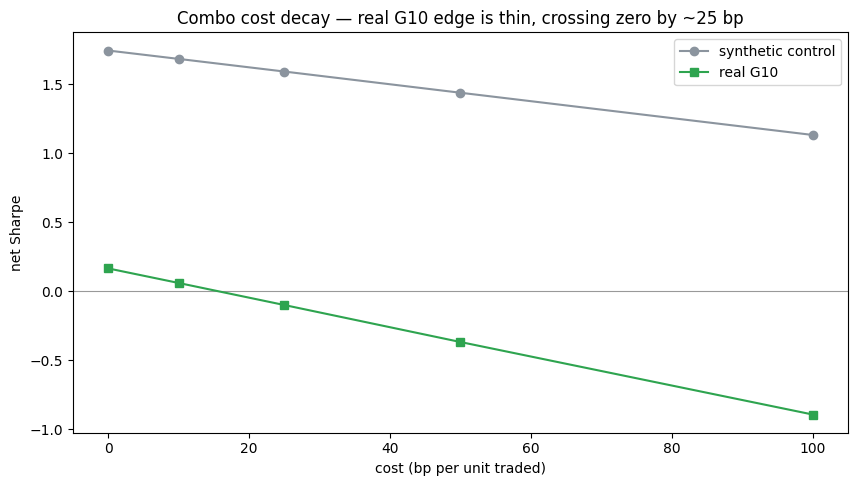

In [7]:
print('SYNTHETIC control combo cost sweep:')
cs = costs.cost_sweep(xr, rd, which='combo')
display(cs.round(3))
print('REAL G10 combo cost sweep:')
rcs = costs.cost_sweep(rxr, rrd, which='combo')
display(rcs.round(3))
fig, ax = plt.subplots(); ax.axhline(0, color='#999', lw=.8)
ax.plot(cs.index, cs['sharpe'], marker='o', color='#8b949e', label='synthetic control')
ax.plot(rcs.index, rcs['sharpe'], marker='s', color='#2ea44f', label='real G10')
ax.legend(); ax.set_xlabel('cost (bp per unit traded)'); ax.set_ylabel('net Sharpe'); ax.set_title('Combo cost decay — real G10 edge is thin, crossing zero by ~25 bp')
print('real carry break-even:', round(costs.breakeven_cost_bps(rxr, rrd, which='carry'), 1), 'bp')

### 7b · Other forks
- **Optimal combo weight** — sweep `w_carry`, risk-parity vs the realised crisis correlation.
- **Dollar-carry as a third leg** — the LRV dollar factor earns Sharpe +0.17 on the real tape.
- **Crisis-conditional tilt** — lean toward momentum when global FX vol (Brunnermeier-Nagel-Pedersen) is rising.

**The result.** On the synthetic control the carry premium is `REAL` and recovered and the combo beats both legs *with a winning momentum leg*. On the **real G10 tape (2001–2024)** carry is `REAL`-but-thin with its `FRAGILE` steamroller, FX momentum decayed to negative, and the combo `PARTIAL`-ly delivers — cushioning the crash (decorrelated legs) without lifting the Sharpe. Exactly the §8.3/§8.4 thesis, building on Study 27. Fingerprinted writeups in [`../docs/results.md`](../docs/results.md) and [`../docs/extension.md`](../docs/extension.md).